Using CPU. Note: This module is much faster with a GPU.


Using CPU. Note: This module is much faster with a GPU.

========== VALIDATION RESULT ==========
Confidence Score: 100%
✅ No issues detected


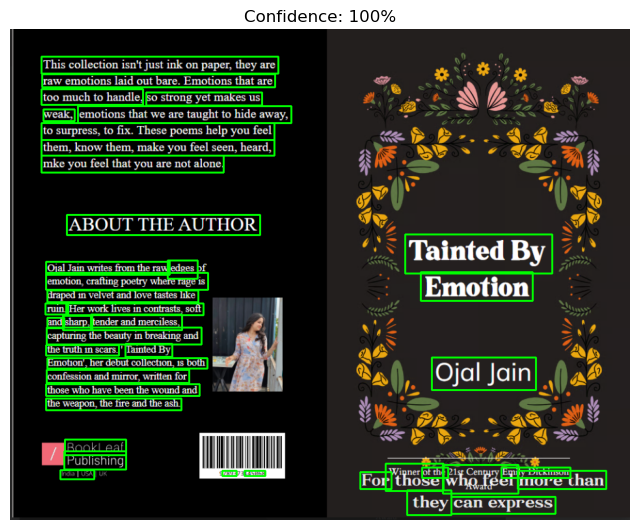

In [3]:
import cv2
import easyocr
import numpy as np
import os
import matplotlib.pyplot as plt

# ----------------------------------
# Initialize EasyOCR
# ----------------------------------
print("Using CPU. Note: This module is much faster with a GPU.")
reader = easyocr.Reader(['en'], gpu=False)


# ----------------------------------
# Load Image Safely
# ----------------------------------
def load_image(image_path):
    if not os.path.exists(image_path):
        print("❌ File not found")
        return None

    image = cv2.imread(image_path)

    if image is None:
        print("❌ Unable to read image. Check format.")
        return None

    return image


# ----------------------------------
# Extract Text Boxes
# ----------------------------------
def extract_text_boxes(image):
    if image is None:
        return []

    results = reader.readtext(image)

    boxes = []

    for (bbox, text, conf) in results:
        x_coords = [point[0] for point in bbox]
        y_coords = [point[1] for point in bbox]

        x_min = int(min(x_coords))
        y_min = int(min(y_coords))
        x_max = int(max(x_coords))
        y_max = int(max(y_coords))

        boxes.append({
            "text": text,
            "conf": conf,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max
        })

    return boxes


# ----------------------------------
# Validation Logic
# ----------------------------------
def validate_cover(image, text_boxes):

    height, width, _ = image.shape

    confidence_score = 100
    issues = []

    # Flags
    badge_overlap = False
    author_violation = False
    side_margin_violation = False
    top_margin_violation = False

    # Define badge restricted zone (top-right 30% width & 20% height)
    badge_x_start = int(width * 0.7)
    badge_y_end = int(height * 0.2)

    for box in text_boxes:

        x_min = box["x_min"]
        y_min = box["y_min"]
        x_max = box["x_max"]
        y_max = box["y_max"]
        text_lower = box["text"].lower()

        # 1️⃣ Badge overlap
        if x_max > badge_x_start and y_min < badge_y_end:
            badge_overlap = True

        # 2️⃣ Author inside badge
        if "author" in text_lower:
            if x_max > badge_x_start and y_min < badge_y_end:
                author_violation = True

        # 3️⃣ Side margin violation (20px safe margin)
        if x_min < 20 or x_max > width - 20:
            side_margin_violation = True

        # 4️⃣ Top margin violation (20px safe margin)
        if y_min < 20:
            top_margin_violation = True

    # 5️⃣ No text detected
    if len(text_boxes) == 0:
        issues.append("❌ No detectable text found")
        confidence_score -= 30

    # Deduct once per issue
    if badge_overlap:
        issues.append("❌ Overlapping text detected in award badge area")
        confidence_score -= 40

    if author_violation:
        issues.append("❌ Author name positioned inside restricted badge zone")
        confidence_score -= 35

    if side_margin_violation:
        issues.append("❌ Text too close to side margins")
        confidence_score -= 15

    if top_margin_violation:
        issues.append("❌ Text too close to top margin")
        confidence_score -= 15

    confidence_score = max(0, confidence_score)

    return {
        "confidence": confidence_score,
        "issues": issues
    }


# ----------------------------------
# Draw Annotations (Matplotlib Version)
# ----------------------------------
def draw_annotations(image, text_boxes, result):

    annotated = image.copy()

    for box in text_boxes:
        cv2.rectangle(
            annotated,
            (box["x_min"], box["y_min"]),
            (box["x_max"], box["y_max"]),
            (0, 255, 0),
            2
        )

    print("\n========== VALIDATION RESULT ==========")
    print(f"Confidence Score: {result['confidence']}%")

    if result["issues"]:
        print("\nIssues Found:")
        for issue in result["issues"]:
            print(issue)
    else:
        print("✅ No issues detected")

    # Convert BGR → RGB
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 10))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(f"Confidence: {result['confidence']}%")
    plt.show()


# ----------------------------------
# MAIN EXECUTION
# ----------------------------------
if __name__ == "__main__":

    # ⚠️ PUT YOUR IMAGE PATH HERE
    image_path = r"C:\Users\MY DELL\Downloads\image (36).png"

    image = load_image(image_path)

    if image is not None:
        text_boxes = extract_text_boxes(image)
        result = validate_cover(image, text_boxes)
        draw_annotations(image, text_boxes, result)